# Download OW Faults from a specific Project via dsis-python-client

This notebook demonstrates how to query and explore fault data from DSIS using the `dsis-client` library.

For more information about the required content of the `.env_dsis` file, please contact the SDD-SID team or the DSIS team in Equinor.


## OpenWorks fault schema overview

OpenWorks organises fault data across several related schemas. Understanding how they connect is key to querying and interpreting the data correctly.

### The two-level fault model

A fault exists at two distinct levels in OpenWorks:

**1. The named geological concept — `Fault`**

A `Fault` record represents a geological fault as a named entity (e.g. `"F47"`). It carries high-level attributes that describe the fault as a whole: type (normal, reverse, strike-slip), maximum heave, and vertical separation. These properties belong to the concept, not to any one interpretation.

**2. The interpreted surface — `FaultPlane`, `FaultSegment`, `FaultTrimesh`, `FaultCenterLine`**

A `FaultPlane` is one specific interpretation of a named fault's geometry. The same geological fault can have multiple planes — interpreted by different users, at different times, or from different seismic vintages. Each `FaultPlane` has a unique integer `native_uid`, which is used as `fault_plane_id` throughout all geometry schemas.

**Example**
```
Fault "Volve_F47_2011" native_uid = 'Volve_F47_2011', 'id = '10191'
    ├── FaultPlane native_uid=4104  (interpreted by AAKA in 2011)
    ├── FaultPlane native_uid=5201  (reinterpreted by HEIGU in 2014)
    └── FaultPlane native_uid=6033  (QC version, 2016)
```
Geometry is stored in one of three schemas, depending on how the project was set up:

| Schema | Description |
|---|---|
| `FaultSegment` | Polyline cross-sections (one per horizon). Multiple segments together define a full fault surface. The most common representation. |
| `FaultTrimesh` | A 3-D triangulated mesh surface. A compact alternative to segments for depth-converted or gridded interpretations. |
| `FaultCenterLine` / `FaultCenterLineSet` | A single line along the centre of the fault plane, derived from picks. Used in some workflows as a lightweight representation. |

All three geometry schemas reference `FaultPlane` via `fault_plane_id`.

### Organisation into lists — `FaultList` and `FaultListMember`

Fault planes are grouped into named collections called `FaultList` (e.g. `"All faults for VOLVE_PUB"`). The join table `FaultListMember` records which `FaultPlane` (`fault_plane_id`) belongs to which `FaultList` (`list_id`). This is the entry point used when users select a set of faults for transfer or export.

## Schema relationship summary

```
FaultList  ←──── FaultListMember ────►  FaultPlane (native_uid = fault_plane_id)
                                              │
                       ┌──────────────────────┼──────────────────────┐
                       ▼                      ▼                      ▼
                 FaultSegment           FaultTrimesh          FaultCenterLine
                 (polylines)           (triangle mesh)         (centre line)

FaultPlane.fault_name
       │
       ├──► Fault.name                                     (type, heave, displacement)
       └──► FaultDisplay.name and FaultDisplay.data_source (colour, line style)
```

## 1. Setup

Import dependencies and authenticate to DSIS. Credentials and API keys are loaded from an `.env_dsis` file in the working directory. The file must contain the following keys: `tenant_id`, `client_id`, `client_secret`, `resource_id`, `dsis_function_key`, `dsis_password`, `subscription_key_dsauth`, `subscription_key_dsdata`, and optionally `dsis_site`.


In [2]:
%matplotlib inline
from dotenv import load_dotenv
import os
import matplotlib.pyplot as plt
from collections import defaultdict
from typing import Iterable
import inspect
from dsis_client import DSISClient, DSISConfig, QueryBuilder, Environment

In [3]:
load_dotenv(".env_dsis")

True

In [4]:
config = DSISConfig(
    environment=Environment.PROD,
    tenant_id=os.getenv("tenant_id"),
    client_id=os.getenv("client_id"),
    client_secret=os.getenv("client_secret"),
    access_app_id=os.getenv("resource_id"),
    dsis_username=os.getenv("dsis_function_key"),
    dsis_password=os.getenv("dsis_password"),
    subscription_key_dsauth=os.getenv("subscription_key_dsauth"),
    subscription_key_dsdata=os.getenv("subscription_key_dsdata"),
    dsis_site=os.getenv("dsis_site"),
)

In [5]:
dsis_client = DSISClient(config)
if dsis_client.test_connection():
    print("✓ Connected to DSIS API")

✓ Connected to DSIS API


## 2. Query parameters

Set the OpenWorks model, model version, database (district), and project to query.

- `MODEL_NAME` — the OW model used to interpret the faults (e.g. `OW5000`). Controls the `district_id` format and which schemas are available.
- `MODEL_VERSION` — the schema version deployed in this DSIS instance.
- `DISTRICT` — the OpenWorks database name (used to build the `district_id`).
- `PROJECT` — the OpenWorks project containing the fault data.


In [6]:
MODEL_NAME = "OW5000"
MODEL_VERSION = "5000107"
DISTRICT = "BG4FROST"
PROJECT = "VOLVE_PUBLIC"

In [7]:
def build_district_id(database: str, *, model_name: str) -> str:
    """Build DSIS district_id from database name.

    DSIS uses different district-id conventions for different models.

    Examples:
    - OpenWorksCommonModel: OpenWorksCommonModel_OW_<DB>-OW_<DB>
    - OpenWorks native models (e.g., OW5000): OpenWorks_OW_<DB>_SingleSource-OW_<DB>
    """
    if model_name == "OpenWorksCommonModel":
        return f"OpenWorksCommonModel_OW_{database}-OW_{database}"
    return f"OpenWorks_OW_{database}_SingleSource-OW_{database}"


qkw: dict = {
    "district_id": build_district_id(DISTRICT, model_name=MODEL_NAME),
    "project": PROJECT,
}
if "model_name" in inspect.signature(QueryBuilder).parameters:
    qkw["model_name"] = MODEL_NAME

## 3. Examples

The helper function `plot_fault_map` takes a flat list of `FaultSegment` dicts and renders them as a 2-D plan-view (easting/northing) map. Each unique `fault_plane_id` is assigned a distinct colour (cycling through 20). X/Y units and axis labels are read directly from the segment metadata.


The examples below show three common query patterns, from broad (all fault planes in the project) to specific (a single plane with full metadata).

In [8]:
def plot_fault_map(segments: Iterable[dict]) -> None:
    """Plot all faults as 2-D plan-view polylines, one colour per fault_plane_id.

    X = projected easting  (unit read from bounding_pt1_x_dsdsunit)
    Y = projected northing (unit read from bounding_pt1_y_dsdsunit)
    """
    by_plane: dict = defaultdict(list)
    x_unit = "None"
    y_unit = "None"
    for seg in segments:
        by_plane[seg["fault_plane_id"]].append(seg)
        x_unit = seg.get("bounding_pt1_x_dsdsunit")
        y_unit = seg.get("bounding_pt1_y_dsdsunit")

    if not by_plane:
        print("No segments to plot.")
        return

    plane_ids = list(by_plane.keys())
    cmap = plt.colormaps["tab20"]
    colours = [cmap(i % 20) for i in range(len(plane_ids))]

    fig, ax = plt.subplots(figsize=(10, 10))

    for colour, pid in zip(colours, plane_ids):
        for seg in by_plane[pid]:
            vals = seg["values"]
            x = [float(v) for v in vals["x"]]
            y = [float(v) for v in vals["y"]]
            ax.plot(x, y, color=colour, linewidth=1.0)

    n = len(plane_ids)
    ax.set_title(f"{PROJECT} — {n} fault{'s' if n != 1 else ''}")
    ax.set_aspect("equal")
    ax.grid(True, linewidth=0.4)
    ax.set_xlabel(f"Easting ({x_unit})")
    ax.set_ylabel(f"Northing ({y_unit})")
    plt.xticks(rotation=-70)
    plt.tight_layout()
    plt.show()

### 3.1 Example: Count fault planes in a FaultList

This example queries `FaultListMember` filtered by a known `list_id` to count how many fault planes belong to that list.

A `FaultList` groups fault planes into a named collection (e.g. a set selected for transfer). `FaultListMember` is the join table that links each `FaultPlane` to its `FaultList` via `fault_plane_id` and `list_id`.

In [28]:
# Build and execute the query
query = QueryBuilder(**qkw).schema("FaultListMember").filter("list_id eq 140")

fault_list_members = list(dsis_client.execute_query(query, timeout=60))

# Print result
print(
    f"Example: Fault list list_id = 140 contains "
    f"{len(fault_list_members)} fault list members found"
)

Example: Fault list list_id = 140 contains 65 fault list members found


In [ ]:
fault = list(
    dsis_client.execute_query(
        QueryBuilder(**qkw).schema("FaultDisplay"),
        timeout=250,
    )
)


fault_plane = list(
    dsis_client.execute_query(
        QueryBuilder(**qkw).schema("FaultPlane"),
        timeout=250,
    )
)
fault

[{'create_user_id': 'AAKA',
  'native_uid': '{"name":"Volve_F1_east_2011","data_source":"AAKA"}',
  'color': 56,
  'line_style': 1,
  'data_source': 'AAKA',
  'color_r': 20,
  'update_date': None,
  'display_ind': 1,
  'original_data_source': 'AAKA',
  'color_g': 173,
  'update_user_id': None,
  'name': 'Volve_F1_east_2011',
  'line_weight': 1,
  'create_date': '2011-06-20T16:22:19.000',
  'color_b': 104},
 {'create_user_id': 'AAKA',
  'native_uid': '{"name":"Volve_F1_2011","data_source":"AAKA"}',
  'color': 54,
  'line_style': 1,
  'data_source': 'AAKA',
  'color_r': 131,
  'update_date': None,
  'display_ind': 1,
  'original_data_source': 'AAKA',
  'color_g': 49,
  'update_user_id': None,
  'name': 'Volve_F1_2011',
  'line_weight': 1,
  'create_date': '2011-06-24T15:29:21.000',
  'color_b': 151},
 {'create_user_id': 'AAKA',
  'native_uid': '{"name":"Volve_F2_2011","data_source":"AAKA"}',
  'color': 14,
  'line_style': 1,
  'data_source': 'AAKA',
  'color_r': 37,
  'update_date': None

In [67]:
[k["id"] for k in fault]

['0',
 '10138',
 '10140',
 '10141',
 '10142',
 '10143',
 '10144',
 '10145',
 '10146',
 '10148',
 '10149',
 '10150',
 '10151',
 '10153',
 '10181',
 '10182',
 '10183',
 '10184',
 '10185',
 '10186',
 '10187',
 '10188',
 '10189',
 '10170',
 '10171',
 '10172',
 '10173',
 '10174',
 '10175',
 '10176',
 '10177',
 '10178',
 '10179',
 '10180',
 '10409',
 '10159',
 '10160',
 '10161',
 '10162',
 '10163',
 '10165',
 '10166',
 '10167',
 '10168',
 '10169',
 '10403',
 '10404',
 '10406',
 '10408',
 '10190',
 '10191',
 '10192',
 '10193',
 '10194',
 '10195',
 '10196',
 '10197',
 '10198',
 '10199',
 '10416',
 '10356',
 '10387',
 '10390',
 '10391',
 '10392',
 '10395',
 '10396',
 '10397']

### 3.2 Example: Fetch all fault planes and plot their segments

The embedded segments are then flattened into a single list (filtering out any without coordinates) and plotted as a project-wide fault map.

Fetches every `FaultPlane` in the project and uses `.expand()` to inline the related `FaultSegment`, `Fault`, and `FaultListMember` records in a single request, avoiding separate round-trip queries per plane.

In [10]:
print("Fetching all FaultPlanes with embedded segments...")
planes = list(
    dsis_client.execute_query(
        QueryBuilder(**qkw)
        .schema("FaultPlane")
        .expand("FaultSegment,Fault,FaultListMember"),
        timeout=250,
    )
)

all_segments = [
    seg
    for plane in planes
    for seg in plane.get("FaultSegment", [])
    if seg.get("values")
]

n_planes = len({seg["fault_plane_id"] for seg in all_segments})
print(f"  {len(all_segments)} segment(s) across {n_planes} plane(s) with geometry")

Fetching all FaultPlanes with embedded segments...
  1286 segment(s) across 65 plane(s) with geometry


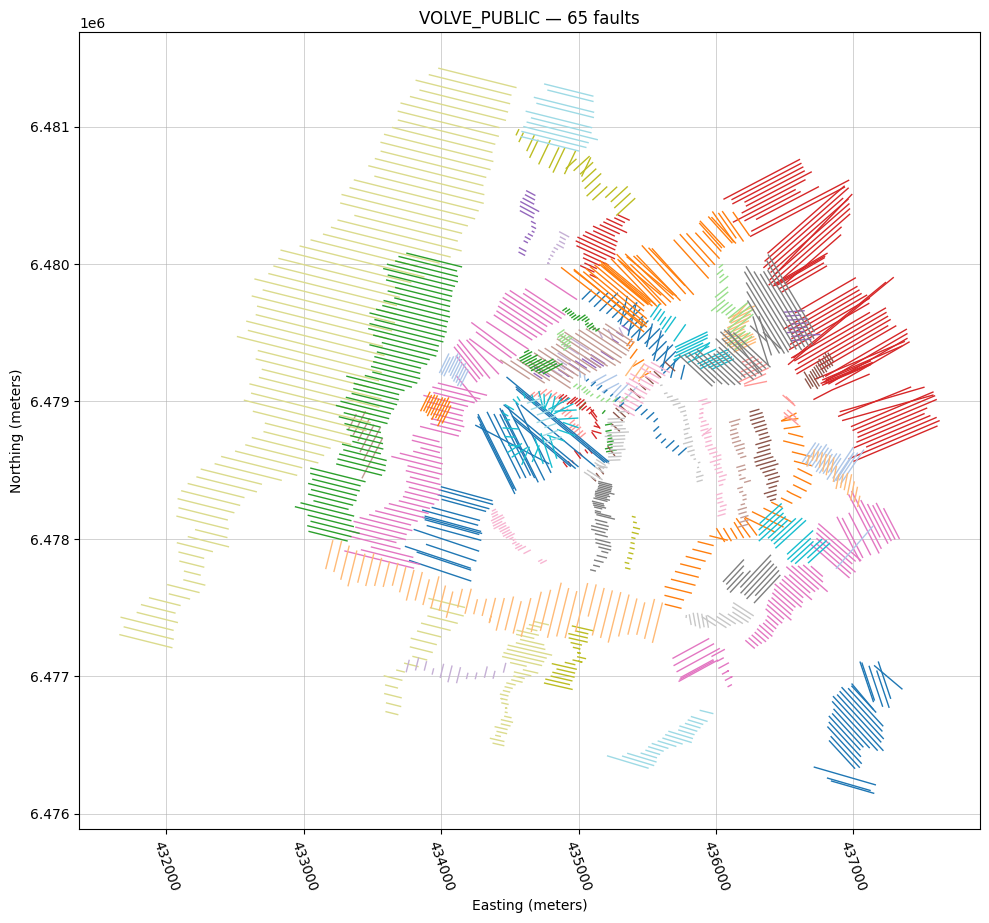

In [11]:
plot_fault_map(all_segments)

### 3.3 Example: Inspect a single fault plane with full metadata

Queries one specific `FaultPlane` by `native_uid` and expands `FaultSegment`, `Fault`, and `FaultListMember` inline. This gives access to:

- **geometry** — the embedded `FaultSegment` polylines (x/y/z coordinates, z-domain, units)- **display style** — queried separately from `FaultDisplay` via `fault_name`

- **geological attributes** — from the expanded `Fault` record (type: normal/reverse/strike-slip, heave, vertical separation)- **list membership** — from `FaultListMember` (which `FaultList` this plane belongs to)

In [12]:
# .expand() is called on the QueryBuilder (before execute_query), not on the result.
# It adds an OData $expand parameter to inline the related FaultSegment records directly
# inside each FaultPlane record, avoiding a second round-trip query.
import pprint

FAULT_PLANE_ID = 4318
(expanded_result,) = list(
    dsis_client.execute_query(
        QueryBuilder(**qkw)
        .schema("FaultPlane")
        .filter(f"native_uid eq {FAULT_PLANE_ID}")
        .expand("FaultSegment,Fault,FaultListMember"),
        timeout=60,
    )
)

plane = expanded_result if expanded_result else {}
embedded_segments = plane.get("FaultSegment", [])
fault = plane.get("Fault", {})
print(f"FaultPlane {FAULT_PLANE_ID}: {len(embedded_segments)} embedded FaultSegment(s)")
print(f"FaultPlane fault_name : {plane.get('fault_name')}")
print(f"FaultPlane z_domain   : {plane.get('z_domain')}")
print()
# Show the first embedded segment
if embedded_segments:
    print("First embedded FaultSegment:")
    pprint.pprint(embedded_segments[0])
print()
# Show the fault
if fault:
    print("Fault:")
    pprint.pprint(fault)

fault_list_member = plane.get("FaultListMember", [])
if fault_list_member:
    print("\nFaultListMember:")
    pprint.pprint(fault_list_member)

FaultPlane 4318: 17 embedded FaultSegment(s)
FaultPlane fault_name : ST10010_2013b_171013_m
FaultPlane z_domain   : TIME

First embedded FaultSegment:
{'bounding_pt1_x': '434962.892232391',
 'bounding_pt1_x_dsdsunit': 'meters',
 'bounding_pt1_y': '6478768.42863321',
 'bounding_pt1_y_dsdsunit': 'meters',
 'bounding_pt2_x': '434962.892232391',
 'bounding_pt2_x_dsdsunit': 'meters',
 'bounding_pt2_y': '6478768.42863321',
 'bounding_pt2_y_dsdsunit': 'meters',
 'bounding_pt3_x': '435014.22599333',
 'bounding_pt3_x_dsdsunit': 'meters',
 'bounding_pt3_y': '6478811.47444379',
 'bounding_pt3_y_dsdsunit': 'meters',
 'bounding_pt4_x': '435014.22599333',
 'bounding_pt4_x_dsdsunit': 'meters',
 'bounding_pt4_y': '6478811.47444379',
 'bounding_pt4_y_dsdsunit': 'meters',
 'create_date': '2013-10-28T13:42:13.000',
 'create_user_id': 'IHD',
 'crs_id': 806,
 'data_source': 'STAT',
 'fault_plane_id': 4318,
 'fault_segment_id': '346700',
 'geom_set_type': '3D Survey',
 'horizon_attr_hdr_id': None,
 'max_x':

In [16]:
n_faults = len({s["fault_plane_id"] for s in embedded_segments})
print(
    f"  {len(embedded_segments)} segment(s) for fault_plane_id={FAULT_PLANE_ID} across {n_faults} fault plane(s)"
)

  17 segment(s) for fault_plane_id=4318 across 1 fault plane(s)


Plot the segments of the selected fault plane. Since only one plane is queried here, all polylines are drawn in the same colour.


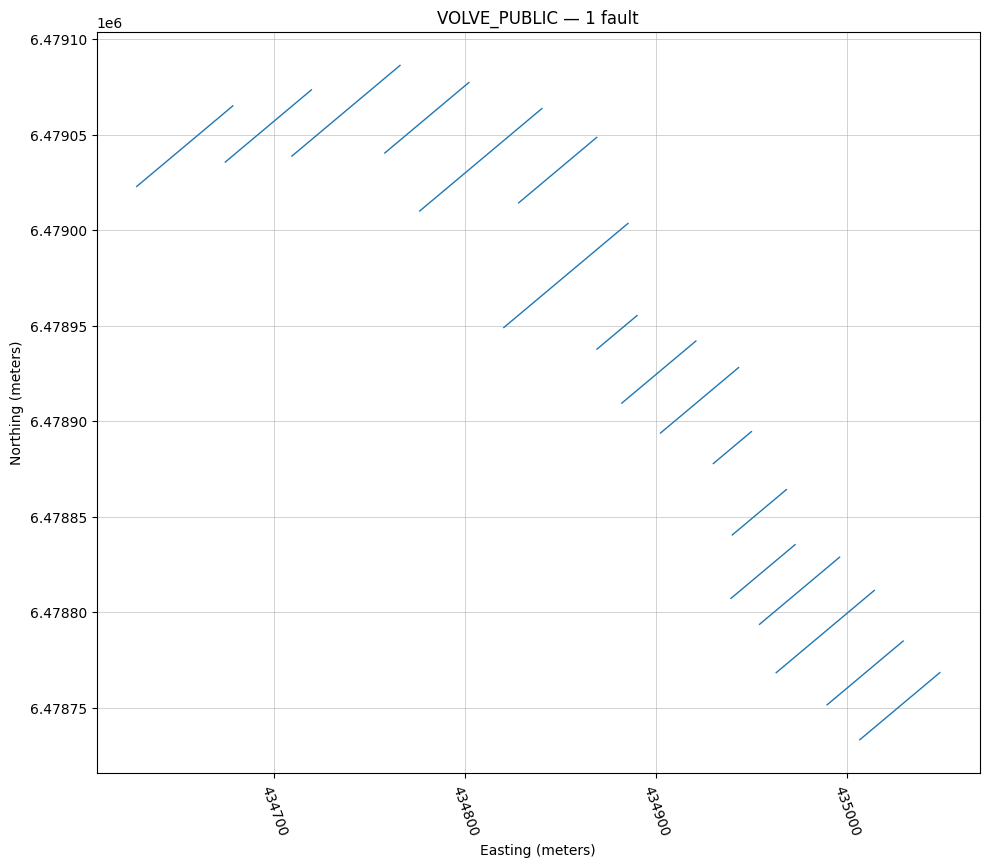

In [17]:
plot_fault_map(embedded_segments)

In [74]:
# FaultDisplay — display colour and line style, joined by name and data_source
(display,) = list(
    dsis_client.execute_query(
        QueryBuilder(**qkw)
        .schema("FaultDisplay")
        .filter(
            f"name eq '{plane['fault_name']}' and data_source eq '{plane['original_data_source']}'"
        ),
        timeout=60,
    )
)
print("FaultDisplay")
for key, value in display.items():
    print(f"  {key:<30} : {value}")

FaultDisplay
  create_user_id                 : IHD
  native_uid                     : {"name":"ST10010_2013b_171013_m","data_source":"IHD"}
  color                          : 38
  line_style                     : 1
  data_source                    : IHD
  color_r                        : 255
  update_date                    : 2013-10-28T13:44:14.000
  display_ind                    : 1
  original_data_source           : IHD
  color_g                        : 153
  update_user_id                 : IHD
  name                           : ST10010_2013b_171013_m
  line_weight                    : 1
  create_date                    : 2013-10-28T13:41:23.000
  color_b                        : 255


## Explore additional fault-related schemas

Beyond `FaultSegment` and `FaultPlane`, DSIS exposes several other schemas for a given fault plane. The following schemas may be relevant for other projects. The cells below query each one and print the results.

| Schema | What it contains | 
|---|---|
| `FaultTrimesh` | 3-D triangulated mesh per fault plane — alternative to polyline `FaultSegment`s |
| `FaultCenterLine` | Centerline geometry (pick-based representation) |
| `FaultCenterLineSet` | Collection of centerlines |

In the Volve public dataset, only `FaultListMember` and `FaultList` return records for fault plane 4321. `FaultTrimesh` and `FaultCenterLine` are absent because this project stores only polyline segments.


In [19]:
print(
    "\nFaultTrimesh (if present) — 3D triangulated surface for fault plane; native_uid is the fault_plane_id"
)
print(
    list(
        dsis_client.execute_query(
            QueryBuilder(**qkw).schema("FaultTrimesh"), timeout=60
        )
    )
)
print(
    "\nFaultCenterLine — 3D line along centre of fault plane; native_uid is the fault_plane_id"
)
print(
    list(
        dsis_client.execute_query(
            QueryBuilder(**qkw).schema("FaultCenterLine"), timeout=60
        )
    )
)
print(
    "\nFaultCenterLineSet — set of 3D lines for all faults; native_uid is the fault_plane_id"
)
print(
    list(
        dsis_client.execute_query(
            QueryBuilder(**qkw).schema("FaultCenterLineSet"), timeout=60
        )
    )
)


FaultTrimesh (if present) — 3D triangulated surface for fault plane; native_uid is the fault_plane_id
[]

FaultCenterLine — 3D line along centre of fault plane; native_uid is the fault_plane_id
[]

FaultCenterLineSet — set of 3D lines for all faults; native_uid is the fault_plane_id
[]
